# ML Lab Part II – Model Training & Hyperparameter Optimization

## Goal
Train different classification algorithms on the feature dataset from Part I
and optimize their hyperparameters.

## Workflow
```
Load data → Train/Test-Split → Train classifier →
Measure performance → Optimize hyperparameters
```

**Prerequisite:** `data/feature_data.csv` from Part I must exist.

## Setup

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings; warnings.filterwarnings('ignore')

DATA_DIR = Path("data")
ACTIVITIES = {1: "Walking", 2: "Standing", 3: "Squats", 4: "SpinAround"}

---
## Task 1 – Load data

Load the feature dataset from Part I. We start with the one that provides only the 4 activities. 

**Hint:** `pd.read_csv()`, vizualize at the table, then separate features (X) and labels (y).
The `label` column contains the class labels.

In [146]:
# TODO: load feature_data.csv
# X = all columns except 'label'
# y = 'label' column
df = pd.read_csv(DATA_DIR/"feature_data.csv")
X  = df.iloc[:,:24]
y  = df.iloc[:,-1]

print(f"Dataset: {X.shape[0]} Samples, {X.shape[1]} Features")
print(f"Classes: {np.unique(y)}")

Dataset: 561 Samples, 24 Features
Classes: [1. 2. 3. 4.]


---
## Task 2 – Train/Test-Split

Split the dataset into **85% training** and **15% test**.
The test split is not used for training. In this lab, we will also inspect it once in Task 3 to compare it with cross-validation, but do not use it to choose or tune models.

**Hints:**
- use `stratify=y` to ensure that all classes are distributed evenly

In [147]:
# TODO: split the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=3,stratify=y,test_size=0.15)

print(f"Training:  {X_train.shape[0]} Samples")
print(f"Test:      {X_test.shape[0]} Samples")

Training:  476 Samples
Test:      85 Samples


---
## Task 3 – Train and compare classifiers

Train at least the following three classifiers on the training data:

| Class | sklearn |
|---|---|
| Decision Tree | `DecisionTreeClassifier()` |
| k-Nearest Neighbors | `KNeighborsClassifier()` |
| Random Forest | `RandomForestClassifier()` |

For each classifier:
- **a)** Training on `X_train` / `y_train`
- **b)** Training-Accuracy (Resubstitution) with `model.score(X_train, y_train)`
- **c)** Cross-Validation-Accuracy (5-fold) with `cross_val_score(..., cv=5)`
- **d)** Test-Accuracy with `model.score(X_test, y_test)`

**Own research:** We did not cover `cross_val_score` in detail in the lecture. Familiarize yourself with the goal of **k-fold cross validation**: Why is the training data split into several folds, why is a fresh model trained for each fold, and why can this give a better estimate than only checking the training accuracy?

**Hint:** `cross_val_score` returns an array; use the mean with `.mean()`.
Compare the cross-validation accuracy with the test accuracy. This test-score comparison is included here for learning purposes only. In a clean ML workflow, the test set should not be used to choose between models or tune hyperparameters.

Is there a difference between cross-validation accuracy and test accuracy in your case? If yes, what could explain it?

<div style="border: 1px solid #999; padding: 10px; min-height: 120px; background: #fafafa;">
<strong>Your explanation:</strong><br><br>
Write your explanation here.
</div>

In [148]:
models = {
    "Decision Tree":  DecisionTreeClassifier(random_state=42),
    "k-NN":           KNeighborsClassifier(),
    "Random Forest":  RandomForestClassifier(random_state=42),
}

#Train and evaluate all models An Output similar to this (values might differ)
#Decision Tree         Resub: 1.000  CV: 0.982 Test: 0.960
#k-NN                  Resub: 0.996  CV: 0.993 Test: 1.000
#Random Forest         Resub: 1.000  CV: 0.993 Test: 1.000
for modelName, model in models.items():
    clf = model
    clf.fit(X_train,y_train)
    training_accuracy = clf.score(X_train,y_train)
    CV_score = np.mean(cross_val_score(clf,X_train,y_train,cv=5))
    test_accuracy = clf.score(X_test,y_test)
    print(f'#{modelName} \t\t Resub: {round(training_accuracy,3)}  CV: {round(CV_score,3)} Test: {round(test_accuracy,3)}')

#Decision Tree 		 Resub: 1.0  CV: 0.922 Test: 0.953
#k-NN 		 Resub: 0.954  CV: 0.933 Test: 0.941
#Random Forest 		 Resub: 1.0  CV: 0.958 Test: 0.965


---
## Task 4 – Compare with another group's data

Ask another group for their feature dataset from Part I and use it as an additional check: Are the cross-validation results from your own training data comparable to the accuracy on data recorded by another group?

Use this exact filename so everyone follows the same convention:

```text
data/feature_data_external.csv
```

The file must have the same structure as your own `feature_data.csv`: the same feature columns and a `label` column with the same activity labels.

Evaluate the models from Task 3 on this external dataset and compare the result with the CV accuracy from Task 3.

If the external accuracy is much lower than the CV accuracy, investigate the reason: Join your dataset and the external dataset, train new classifiers on the joined data, and compare whether the results improve. This can show whether the original model learned patterns that were too specific to your own group's recordings.

<div style="border: 1px solid #999; padding: 10px; min-height: 120px; background: #fafafa;">
<strong>Your explanation:</strong><br><br>
Are the external-data accuracies comparable to the cross-validation accuracies? Does training on the joined dataset improve the result? What could explain the difference?


</div>

In [149]:
external_file = DATA_DIR / "feature_data_external.csv"

# TODO: load the external feature dataset
# TODO: create X_external and y_external
# TODO: evaluate each model from Task 3 on the external dataset
# TODO: compare external accuracy with the CV accuracy from Task 3
# TODO: join your dataset and the external dataset
# TODO: train new classifiers on the joined dataset
# TODO: compare the new CV accuracy with the previous external accuracy
df_external = pd.read_csv(external_file)
X_external = df_external.iloc[:,:-1]
y_external = df_external.iloc[:,-1]
print(f"Dataset: {X_external.shape[0]} Samples, {X_external.shape[1]} Features")
print(f"Classes: {np.unique(y_external)}")
for modelName, model in models.items():
    clf = model
    #training_accuracy_external = clf.score(X_external,y_train_external)
    CV_score_external = np.mean(cross_val_score(clf,X_external,y_external,cv=5))
    test_accuracy_external = clf.score(X_external,y_external)
    print(f'# External {modelName} \t\t CV: {round(CV_score_external,3)} Test: {round(test_accuracy_external,3)}')
df_combined = pd.concat((df,df_external))

X_combined = df_combined.iloc[:,:24]
y_combined = df_combined.iloc[:,-1]
#X_train_combined,X_test_combined,y_train_combined,y_test_combined = train_test_split(X_combined,y_combined,random_state=3)
for modelName, model in models.items():
    clf = model
    #training_accuracy_external = clf.score(X_external,y_train_external)
    CV_score_combined = np.mean(cross_val_score(clf,X_combined,y_combined,cv=5))
    test_accuracy_combined = clf.score(X_combined,y_combined)
    print(f'# Combined {modelName} \t\t CV: {round(CV_score_combined,3)} Test: {round(test_accuracy_combined,3)}')

Dataset: 345 Samples, 24 Features
Classes: [1 2 3 4]
# External Decision Tree 		 CV: 0.843 Test: 0.296
# External k-NN 		 CV: 0.925 Test: 0.243
# External Random Forest 		 CV: 0.936 Test: 0.481
# Combined Decision Tree 		 CV: 0.843 Test: 0.727
# Combined k-NN 		 CV: 0.887 Test: 0.682
# Combined Random Forest 		 CV: 0.929 Test: 0.799


---
## Task 5 – Train classifiers for all 8 activities

In Part I, you created a larger feature dataset with all 8 activity classes. Now repeat the training and comparison from Task 3 with this larger dataset.

Use this exact filename:

```text
data/large_feature_data.csv
```

The expected labels are:

| Label | Activity |
|---|---|
| 1 | Walking |
| 2 | Standing |
| 3 | Squats |
| 4 | SpinAround |
| 5 | Boxing |
| 6 | Jumping |
| 7 | KneeRaise |
| 8 | WalkingBackward |

Train the same classifiers as before and compare training accuracy, 5-fold cross-validation accuracy, and test accuracy. Does the classification problem become harder when all 8 classes are included?

<div style="border: 1px solid #999; padding: 10px; min-height: 120px; background: #fafafa;">
<strong>Your explanation:</strong><br><br>
Compare the 8-class results with the 4-class results. Which classes or models seem more difficult, and why?
</div>

In [150]:
large_file = DATA_DIR / "large_feature_data.csv"
models_large = {
    "Decision Tree":  DecisionTreeClassifier(random_state=42),
    "k-NN":           KNeighborsClassifier(),
    "Random Forest":  RandomForestClassifier(random_state=42),
}
# TODO: load large_feature_data.csv
# TODO: create X_large and y_large
# TODO: split into training and test data
# TODO: train the same classifiers as in Task 3
# TODO: compare resubstitution, CV, and test accuracy
df_large = pd.DataFrame(pd.read_csv(large_file))
X_large = df_large.iloc[:,:24]
y_large = df_large.iloc[:,-1]
print(np.unique(y_large))
X_large_train, X_large_test, y_large_train, y_large_test = train_test_split(X_large,y_large,random_state=3,stratify=y_large,test_size=0.15)
for modelName, model in models_large.items():
    clf = model
    clf.fit(X_large_train,y_large_train)
    training_accuracy = clf.score(X_large_train,y_large_train)
    CV_score = np.mean(cross_val_score(clf,X_large_train,y_large_train,cv=5))
    test_accuracy = clf.score(X_large_test,y_large_test)
    print(f'#{modelName} \t\t Resub: {round(training_accuracy,3)}  CV: {round(CV_score,3)} Test: {round(test_accuracy,3)}')


[1. 2. 3. 4. 5. 6. 7. 8.]
#Decision Tree 		 Resub: 1.0  CV: 0.87 Test: 0.9
#k-NN 		 Resub: 0.935  CV: 0.909 Test: 0.933
#Random Forest 		 Resub: 1.0  CV: 0.93 Test: 0.961


---
## Task 6 – Plot a prediction crosstab

Accuracy gives only one number. To understand which activities are confused with each other, create a crosstab of true labels vs. predicted labels for the 8-class test set from Task 5.

Use one trained model from Task 5, for example the Random Forest model. Then:

- predict the labels for `X_test_large`
- create a crosstab with `pd.crosstab(...)`
- display the crosstab as a table
- plot the same values as a heatmap

<div style="border: 1px solid #999; padding: 10px; min-height: 120px; background: #fafafa;">
<strong>Your explanation:</strong><br><br>
Which activities are confused most often? Does this match your expectation from the movements?
</div>

col_0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
Label,,,,,,,,
1.0,25,0,0,2,0,0,0,2
2.0,2,29,0,0,0,0,0,0
3.0,0,0,15,0,0,0,0,0
4.0,0,0,0,19,0,0,0,0
5.0,0,0,0,0,27,0,0,1
6.0,0,0,0,0,0,14,0,0
7.0,0,0,0,0,0,0,15,0
8.0,0,0,0,0,0,0,0,29


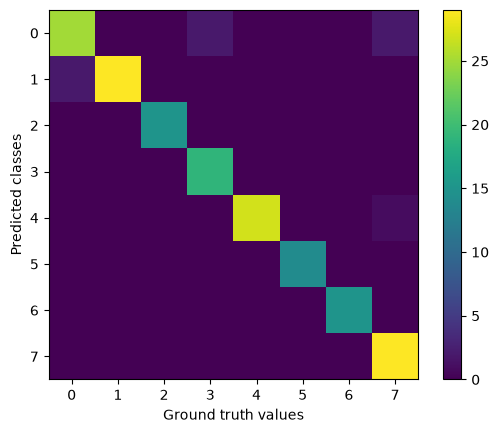

In [151]:
# TODO: select one model from Task 5, for example Random Forest
# TODO: predict labels for X_test_large
# TODO: create a crosstab with pd.crosstab(...)
# TODO: display the crosstab
# TODO: plot the crosstab as a heatmap
model = models_large["Random Forest"]
y_labels_predicted = model.predict(X_large_test)

crossTab = pd.crosstab(y_large_test,y_labels_predicted)

display(crossTab)
plt.imshow(crossTab,cmap='viridis')
plt.xlabel("Ground truth values")
plt.ylabel("Predicted classes")
plt.colorbar()

---
## Task 7 – Automatic hyperparameter optimization

So far, you trained classifiers mostly with their default settings. Many machine-learning algorithms have **hyperparameters**: settings that are chosen before training and can strongly influence the result. Examples are the maximum depth of a decision tree, the number of neighbors in k-NN, or the number and depth of trees in a random forest.

Trying these settings manually is slow and can easily become inconsistent. In this task, you let scikit-learn test several hyperparameter combinations automatically. The important point is that the search uses **cross-validation on the training data**. The test set should not be used to decide which hyperparameters are best.

You will optimize three algorithms and compare two common search strategies:

| Algorithm | Search strategy | Example hyperparameters |
|---|---|---|
| Decision Tree | `GridSearchCV` | `max_depth`, `min_samples_split`, `criterion` |
| k-NN | `RandomizedSearchCV` | `n_neighbors`, `weights`, `metric` |
| Random Forest | `RandomizedSearchCV` | `n_estimators`, `max_depth`, `min_samples_split` |

After the searches, compare the best cross-validation score of each optimized model with the default models from Task 3.

You will use these two search strategies:

### a) Grid Search
Searches **all** combinations in the defined grid.
```python
GridSearchCV(estimator, param_grid, cv=5, scoring='accuracy')
```

### b) Random Search
Samples **random** combinations from the search space (faster for large spaces).
```python
RandomizedSearchCV(estimator, param_distributions, n_iter=20, cv=5)
```

**Hints:**
- `.best_params_` shows the best parameters found
- `.best_score_` shows the best CV accuracy
- `.fit(X_train, y_train)` starts the search

In [152]:
# TODO: Grid Search for Decision Tree
param_grid_dt = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
}
grid_dt = GridSearchCV(models["Decision Tree"],param_grid_dt,cv=5,scoring='accuracy')
grid_dt.fit(X_train,y_train)

# TODO: Random Search for k-NN
param_dist_knn = {
    "n_neighbors": range(1, 30),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}
model = models["k-NN"]
rand_knn = RandomizedSearchCV(model,param_dist_knn,n_iter=20,cv=5)
rand_knn.fit(X_train,y_train)

# TODO: Random Search for Random Forest
param_dist_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
}
model = models["Random Forest"]
rand_rf = RandomizedSearchCV(model,param_dist_rf,n_iter=20,cv=5)
rand_rf.fit(X_train,y_train)
optimised_models = {
    "Decision Tree": grid_dt,
    "k-NN": rand_knn,
    "Random Forest": rand_rf

}

# TODO: print results and compare them with default models
print(f'Original Models:')
for Name,model in models.items():
    print(f"#{Name} \t\t Resub: {round(model.score(X_train,y_train),3)}, CV: {round(np.mean(cross_val_score(model,X_train,y_train)),3)}, Test Accuracy: {round(model.score(X_test,y_test),3)}")

print("Optimised models")
for Name,model in optimised_models.items():
    print(f"#{Name} \t\t Resub: {round(model.score(X_train,y_train),3)}, CV: {round(np.mean(cross_val_score(model,X_train,y_train)),3)}, Test Accuracy: {round(model.score(X_test,y_test),3)}")



Original Models:
#Decision Tree 		 Resub: 1.0, CV: 0.922, Test Accuracy: 0.953
#k-NN 		 Resub: 0.954, CV: 0.933, Test Accuracy: 0.941
#Random Forest 		 Resub: 1.0, CV: 0.958, Test Accuracy: 0.965
Optimised models
#Decision Tree 		 Resub: 0.989, CV: 0.939, Test Accuracy: 0.953
#k-NN 		 Resub: 1.0, CV: 0.966, Test Accuracy: 1.0
#Random Forest 		 Resub: 1.0, CV: 0.96, Test Accuracy: 0.965


---
## Task 8 – Evaluate the best model on the test set

Choose the best model from Task 7 and evaluate it on the test set.
In a clean ML workflow, the test set should be used only **once**, at the end. In this lab, you already inspected it in Task 3 for comparison; do not use the Task 3 test scores for hyperparameter tuning.

**Hint:** `best_estimator_` contains the already trained best model.

In [153]:
# TODO: select the best model and evaluate it on X_test
best_model = grid_dt.best_estimator_  #(or rand_knn / rand_rf)
test_acc = accuracy_score(y_test, best_model.predict(X_test))
print(f"Test-Accuracy: {test_acc:.3f}")
best_model_knn = rand_knn.best_estimator_
knn_params = rand_knn.best_params_
print(knn_params)
test_acc = accuracy_score(y_test, best_model_knn.predict(X_test))
print(f"Test-Accuracy: {test_acc:.3f}")
best_model_rf = rand_rf.best_estimator_
test_acc = accuracy_score(y_test, best_model_rf.predict(X_test))
print(f"Test-Accuracy: {test_acc:.3f}")



Test-Accuracy: 0.953
{'weights': 'uniform', 'n_neighbors': 1, 'metric': 'manhattan'}
Test-Accuracy: 1.000
Test-Accuracy: 0.965
